In [1]:
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train),(x_test, y_test) = cifar10.load_data()

## Limpieza

In [3]:
# x_train = x_train.astype('float32') / 255
# x_test = x_test.astype('float32') / 255
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [4]:
num_clases = len(np.unique(y_train))
num_clases

10

In [5]:
y_train = to_categorical(y_train, num_clases)
y_test = to_categorical(y_test, num_clases)

In [6]:
split = int(len(x_train)*0.7)
split

35000

## Normalization

In [7]:
mean = np.mean(x_train)
std = np.std(x_train)

In [8]:
x_train = (x_train-mean)/(std+1e-7)
x_test = (x_test-mean)/(std+1e-7)

In [9]:
(x_train, x_valid) = x_train[:split],x_train[split:]
(y_train, y_valid) = y_train[:split],y_train[split:]

print(f'x_train: {x_train.shape[0]}, x_valid: {x_valid.shape[0]}, x_test: {x_test.shape[0]}')

x_train: 35000, x_valid: 15000, x_test: 10000


## Model

In [10]:
base_filtros = 32
w_regularizer = 1e-4

In [11]:
x_train.shape[1:]

(32, 32, 3)

In [12]:
model = Sequential()
# Conv1
model.add(Conv2D(base_filtros, (3,3), padding='same', kernel_regularizer=regularizers.l2(w_regularizer), input_shape=x_train.shape[1:]))
model.add(Activation('relu'))
model.add(BatchNormalization())
# Conv2
model.add(Conv2D(base_filtros, (3,3), padding='same', kernel_regularizer=regularizers.l2(w_regularizer)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
# Conv3
model.add(Conv2D(2*base_filtros, (3,3), padding='same', kernel_regularizer=regularizers.l2(w_regularizer)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
# Conv4
model.add(Conv2D(2*base_filtros, (3,3), padding='same', kernel_regularizer=regularizers.l2(w_regularizer)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
# Conv5
model.add(Conv2D(4*base_filtros, (3,3), padding='same', kernel_regularizer=regularizers.l2(w_regularizer)))
model.add(Activation('relu'))
model.add(BatchNormalization())
#Conv6
model.add(Conv2D(4*base_filtros, (3,3), padding='same', kernel_regularizer=regularizers.l2(w_regularizer)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
#Clasificacion - flatten
model.add(Flatten())
model.add(Dense(num_clases, activation='softmax'))

model.summary()

d:\USUARIO\Desktop\Pc\Estudio\Data\Auto\Data Science\Deep learning\GITHUB\CNN\env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 293,930 (1.12 MB)

 Trainable params: 293,034 (1.12 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
datagen = ImageDataGenerator(rotation_range=15,width_shift_range=0.1,height_shift_range=0.1,horizontal_flip=True,vertical_flip=True)

In [14]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
# hist = model.fit(x_train,y_train, batch_size=64, epochs=100, validation_data=(x_valid, y_valid), shuffle=True)

In [16]:
checkpoint = ModelCheckpoint('Mi_mejor_modelo.keras',verbose=1,save_best_only=True, monitor='val_accuracy')

In [17]:
hist = model.fit(datagen.flow(x_train,y_train, batch_size=128),callbacks=[checkpoint],steps_per_epoch=x_train.shape[0]//128, epochs=120,verbose=2,validation_data=(x_valid,y_valid))

d:\USUARIO\Desktop\Pc\Estudio\Data\Auto\Data Science\Deep learning\GITHUB\CNN\env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/120

Epoch 1: val_accuracy improved from -inf to 0.19487, saving model to Mi_mejor_modelo.keras
273/273 - 103s - 379ms/step - accuracy: 0.3331 - loss: 2.0473 - val_accuracy: 0.1949 - val_loss: 2.8992
Epoch 2/120


C:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Epoch 2: val_accuracy improved from 0.19487 to 0.20093, saving model to Mi_mejor_modelo.keras
273/273 - 7s - 26ms/step - accuracy: 0.4766 - loss: 1.5379 - val_accuracy: 0.2009 - val_loss: 2.8571
Epoch 3/120

Epoch 3: val_accuracy improved from 0.20093 to 0.47767, saving model to Mi_mejor_modelo.keras
273/273 - 90s - 329ms/step - accuracy: 0.4344 - loss: 1.6238 - val_accuracy: 0.4777 - val_loss: 1.5138
Epoch 4/120

Epoch 4: val_accuracy improved from 0.47767 to 0.48060, saving model to Mi_mejor_modelo.keras
273/273 - 7s - 27ms/step - accuracy: 0.4531 - loss: 1.5103 - val_accuracy: 0.4806 - val_loss: 1.5109
Epoch 5/120

Epoch 5: val_accuracy improved from 0.48060 to 0.51567, saving model to Mi_mejor_modelo.keras
273/273 - 90s - 328ms/step - accuracy: 0.4927 - loss: 1.4566 - val_accuracy: 0.5157 - val_loss: 1.4591
Epoch 6/120

Epoch 6: val_accuracy improved from 0.51567 to 0.51927, saving model to Mi_mejor_modelo.keras
273/273 - 7s - 26ms/step - accuracy: 0.5625 - loss: 1.2542 - val_accu

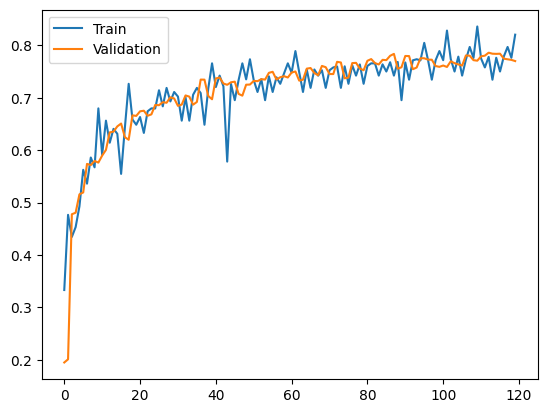

In [18]:
plt.plot(hist.history['accuracy'], label='Train')
plt.plot(hist.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

In [27]:
from tensorflow.keras.models import clone_model

model2 = clone_model(model)
model2.load_weights('Mi_mejor_modelo.keras')

In [28]:
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [29]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7813 - loss: 0.7987


[0.8006537556648254, 0.777999997138977]